In [1]:
!pip install torch torchvision matplotlib pillow scikit-learn

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0


In [3]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

torch.set_float32_matmul_precision("high")

Using Apple MPS GPU


In [4]:
train_dir = "/Users/mithils/TDA/archive/train"
test_dir  = "/Users/mithils/TDA/archive/test"

In [5]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

In [6]:
full_train_dataset = datasets.ImageFolder(train_dir)
test_dataset       = datasets.ImageFolder(test_dir, transform=test_transform)

train_size = int(0.8 * len(full_train_dataset))
val_size   = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform   = test_transform

print(f"Classes     : {full_train_dataset.classes}")
print(f"Train images: {train_size}")
print(f"Val   images: {val_size}")
print(f"Test  images: {len(test_dataset)}")

Classes     : ['FAKE', 'REAL']
Train images: 80000
Val   images: 20000
Test  images: 20000


In [7]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Train batches: 5000 | Val: 1250 | Test: 1250


In [8]:
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 1)
model    = model.to(device)

print("Backbone frozen. Training FC layer only.")

/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Backbone frozen. Training FC layer only.


In [9]:
THRESHOLD      = 0.5
PHASE1_EPOCHS  = 3
PHASE2_EPOCHS  = 5    
LR_PHASE1      = 1e-3
LR_PHASE2      = 1e-5
PATIENCE       = 2    
BEST_MODEL_PATH = "best_model.pth"

criterion = nn.BCEWithLogitsLoss()
print("Config set.")

Config set.


In [10]:
def evaluate(loader):
    model.eval()
    correct    = 0
    total      = 0
    all_preds  = []
    all_labels = []
    all_probs  = []  

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs   = torch.sigmoid(outputs).squeeze()
            preds   = (probs > THRESHOLD).long()

            correct += (preds == labels).sum().item()
            total   += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    accuracy = correct / total
    return accuracy, all_preds, all_labels, all_probs

In [11]:
optimizer1 = optim.Adam(model.fc.parameters(), lr=LR_PHASE1)
scheduler1 = torch.optim.lr_scheduler.StepLR(optimizer1, step_size=2, gamma=0.1)

train_losses   = []
val_accuracies = []
best_val       = 0

print("=== PHASE 1: FC layer only ===")

for epoch in range(PHASE1_EPOCHS):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer1.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer1.step()
        total_loss += loss.item()

    val_acc, _, _, _ = evaluate(val_loader)
    scheduler1.step()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    val_accuracies.append(val_acc)

    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  ✅ Best model saved (val acc: {val_acc*100:.2f}%)")

    print(f"Epoch [{epoch+1}/{PHASE1_EPOCHS}]  Loss: {avg_loss:.4f}  Val Acc: {val_acc*100:.2f}%")

print("\nPhase 1 complete!")

=== PHASE 1: FC layer only ===


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  ✅ Best model saved (val acc: 86.68%)
Epoch [1/3]  Loss: 0.3801  Val Acc: 86.68%
Epoch [2/3]  Loss: 0.3620  Val Acc: 84.04%
  ✅ Best model saved (val acc: 86.91%)
Epoch [3/3]  Loss: 0.3452  Val Acc: 86.91%

Phase 1 complete!


In [14]:
for param in model.parameters():
    param.requires_grad = True

optimizer2 = optim.Adam(model.parameters(), lr=LR_PHASE2)
scheduler2 = torch.optim.lr_scheduler.StepLR(optimizer2, step_size=1, gamma=0.5)

counter = 0

print("=== PHASE 2: Full fine-tuning with early stopping ===")

for epoch in range(PHASE2_EPOCHS):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer2.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer2.step()
        total_loss += loss.item()

    val_acc, _, _, _ = evaluate(val_loader)
    scheduler2.step()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    val_accuracies.append(val_acc)

    if val_acc > best_val:
        best_val = val_acc
        counter  = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  ✅ Best model saved (val acc: {val_acc*100:.2f}%)")
    else:
        counter += 1
        print(f"  ⏳ No improvement ({counter}/{PATIENCE})")

    print(f"Epoch [{epoch+1}/{PHASE2_EPOCHS}]  Loss: {avg_loss:.4f}  Val Acc: {val_acc*100:.2f}%")

    if counter >= PATIENCE:
        print("\n🛑 Early stopping triggered — restoring best model.")
        model.load_state_dict(torch.load(BEST_MODEL_PATH))
        break

print("\nPhase 2 complete!")

=== PHASE 2: Full fine-tuning with early stopping ===


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  ✅ Best model saved (val acc: 97.50%)
Epoch [1/5]  Loss: 0.0711  Val Acc: 97.50%
  ✅ Best model saved (val acc: 97.69%)
Epoch [2/5]  Loss: 0.0421  Val Acc: 97.69%
  ✅ Best model saved (val acc: 97.84%)
Epoch [3/5]  Loss: 0.0305  Val Acc: 97.84%
  ✅ Best model saved (val acc: 97.84%)
Epoch [4/5]  Loss: 0.0234  Val Acc: 97.84%
  ✅ Best model saved (val acc: 97.89%)
Epoch [5/5]  Loss: 0.0221  Val Acc: 97.89%

Phase 2 complete!


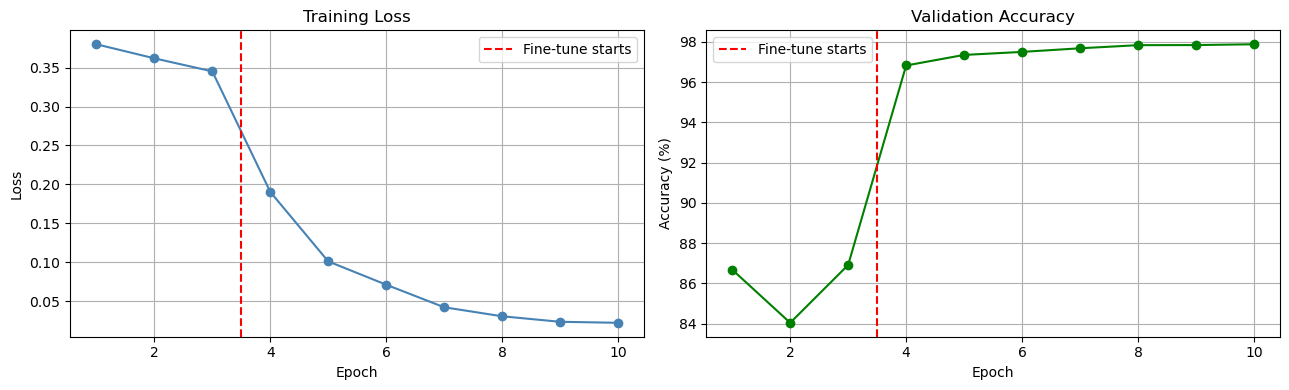

In [15]:
total_epochs = len(train_losses)
epochs_range = range(1, total_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_range, train_losses, marker='o', color='steelblue')
ax1.axvline(x=PHASE1_EPOCHS + 0.5, color='red', linestyle='--', label='Fine-tune starts')
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, [v*100 for v in val_accuracies], marker='o', color='green')
ax2.axvline(x=PHASE1_EPOCHS + 0.5, color='red', linestyle='--', label='Fine-tune starts')
ax2.set_title("Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [16]:
test_acc, preds, labels, probs = evaluate(test_loader)

precision = precision_score(labels, preds)
recall    = recall_score(labels, preds)
f1        = f1_score(labels, preds)
auc       = roc_auc_score(labels, probs)  

print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")
print(f"AUC Score     : {auc:.4f}")

Test Accuracy : 97.67%
Precision     : 0.9803
Recall        : 0.9728
F1 Score      : 0.9766
AUC Score     : 0.9971


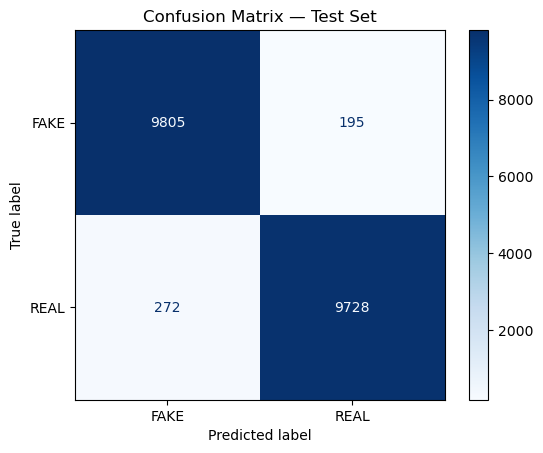

In [17]:
cm   = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["FAKE", "REAL"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set")
plt.show()

In [18]:
def predict_image(path):
    img    = Image.open(path).convert("RGB")
    tensor = test_transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(model(tensor)).item()

    label = "REAL" if prob > THRESHOLD else "FAKE"

    confidence = prob if prob > THRESHOLD else 1 - prob

    plt.imshow(img)
    plt.title(f"Prediction: {label}  |  Confidence: {confidence:.3f}")
    plt.axis("off")
    plt.show()

    return label, confidence



In [19]:
torch.save({
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer2.state_dict(),
    'test_accuracy'       : test_acc,
    'auc_score'           : auc
}, "real_vs_fake_v3_final.pth")

print(f"Saved — Accuracy: {test_acc*100:.2f}% | AUC: {auc:.4f}")

Saved — Accuracy: 97.67% | AUC: 0.9971
